# Employee Attrition Prediction Using Machine Learning
### Third-year student project

**Question:** Can a model distinguish employees labelled as having left from those labelled as having stayed, using the available HR attributes?

**Data:** [IBM HR Analytics on Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset), 1,470 records and 35 columns. This is an educational sample, not a prospective study of future resignations. The dataset has no defined prediction time horizon.

**Workflow:** audit → stratified train/test split → training-only exploration → preprocessing pipelines → five-fold model comparison → final test evaluation → limitations.

Run cells from top to bottom. The final test is for reporting; do not change models based on its results and claim it remains unseen.

## 1. Libraries and reproducibility
Seed 42 fixes the split and randomized model settings. The project requirements record library versions.

In [1]:
"""Reproducible undergraduate ML experiment. Run: python train.py"""
from pathlib import Path
import hashlib
import json
import platform
import os

# Keep Matplotlib's optional cache in this project's writable directory.
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.mplconfig'))

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score,
                             roc_auc_score, PrecisionRecallDisplay)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

ROOT = Path.cwd()
if not (ROOT / 'data' / 'WA_Fn-UseC_-HR-Employee-Attrition.csv').exists():
    ROOT = ROOT / 'employee_turnover'
DATA = ROOT / 'data' / 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
OUT = ROOT / 'results'
SEED = 42




## 2. Load and check the data
The target is `Attrition`: Yes = 1, No = 0. Check missing values, duplicate records, employee IDs and class balance before modelling.

In [2]:
def load_data():
    df = pd.read_csv(DATA)
    if set(df['Attrition'].unique()) != {'Yes', 'No'}:
        raise ValueError('Expected Attrition labels Yes and No.')
    if df['EmployeeNumber'].duplicated().any():
        raise ValueError('Duplicate employee IDs require a grouped split.')
    return df

df = load_data()
print('Shape:', df.shape)
print('Missing cells:', df.isna().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print(df['Attrition'].value_counts())
print(df.head().to_string(index=False))

Shape: (1470, 35)
Missing cells: 0
Duplicate rows: 0
Attrition
No     1233
Yes     237
Name: count, dtype: int64
 Age Attrition    BusinessTravel  DailyRate             Department  DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  EnvironmentSatisfaction Gender  HourlyRate  JobInvolvement  JobLevel               JobRole  JobSatisfaction MaritalStatus  MonthlyIncome  MonthlyRate  NumCompaniesWorked Over18 OverTime  PercentSalaryHike  PerformanceRating  RelationshipSatisfaction  StandardHours  StockOptionLevel  TotalWorkingYears  TrainingTimesLastYear  WorkLifeBalance  YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager
  41       Yes     Travel_Rarely       1102                  Sales                 1          2  Life Sciences              1               1                        2 Female          94               3         2       Sales Executive                4        Single           5993        19479                   8      Y

## 3. Hold out 20% before exploration
Stratification preserves approximately the same class proportions in each subset. `EmployeeNumber` is an identifier; `EmployeeCount`, `StandardHours` and `Over18` are documented constant fields. Gender and marital status are excluded as a project choice, but other inputs can still act as proxies; fairness is not established.

We retain age and work-history inputs for this educational comparison and explicitly acknowledge the limitation. Ordinal numeric survey responses are treated as numeric, which assumes equal spacing for the linear model.

In [3]:
def split_data(df):
    # Explicit design choices, fixed before exploring relationships or test scores.
    # Remove the ID, documented constant fields, and gender/marital status.
    # Excluding two personal attributes does NOT establish fairness; proxies remain.
    excluded = ['Attrition', 'EmployeeNumber', 'EmployeeCount', 'StandardHours',
                'Over18', 'Gender', 'MaritalStatus']
    X = df.drop(columns=excluded)
    y = df['Attrition'].map({'No': 0, 'Yes': 1})
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

X_train, X_test, y_train, y_test = split_data(df)
OUT.mkdir(exist_ok=True)
assert set(X_train.index).isdisjoint(X_test.index)
print('Training:', len(X_train), 'Testing:', len(X_test))
print('Training attrition fraction:', round(y_train.mean(), 4))

Training: 1176 Testing: 294
Training attrition fraction: 0.1616


## 4. Explore training data
Compare the proportion leaving **within each group**, not raw counts across unequal groups. These are associations and do not prove that overtime or satisfaction causes attrition.

                 group  employees  left  attrition_fraction         feature
                    No        836    93               0.111        OverTime
                   Yes        340    97               0.285        OverTime
       Human Resources         48    10               0.208      Department
Research & Development        764   104               0.136      Department
                 Sales        364    76               0.209      Department
                     1        240    53               0.221 JobSatisfaction
                     2        216    38               0.176 JobSatisfaction
                     3        354    58               0.164 JobSatisfaction
                     4        366    41               0.112 JobSatisfaction


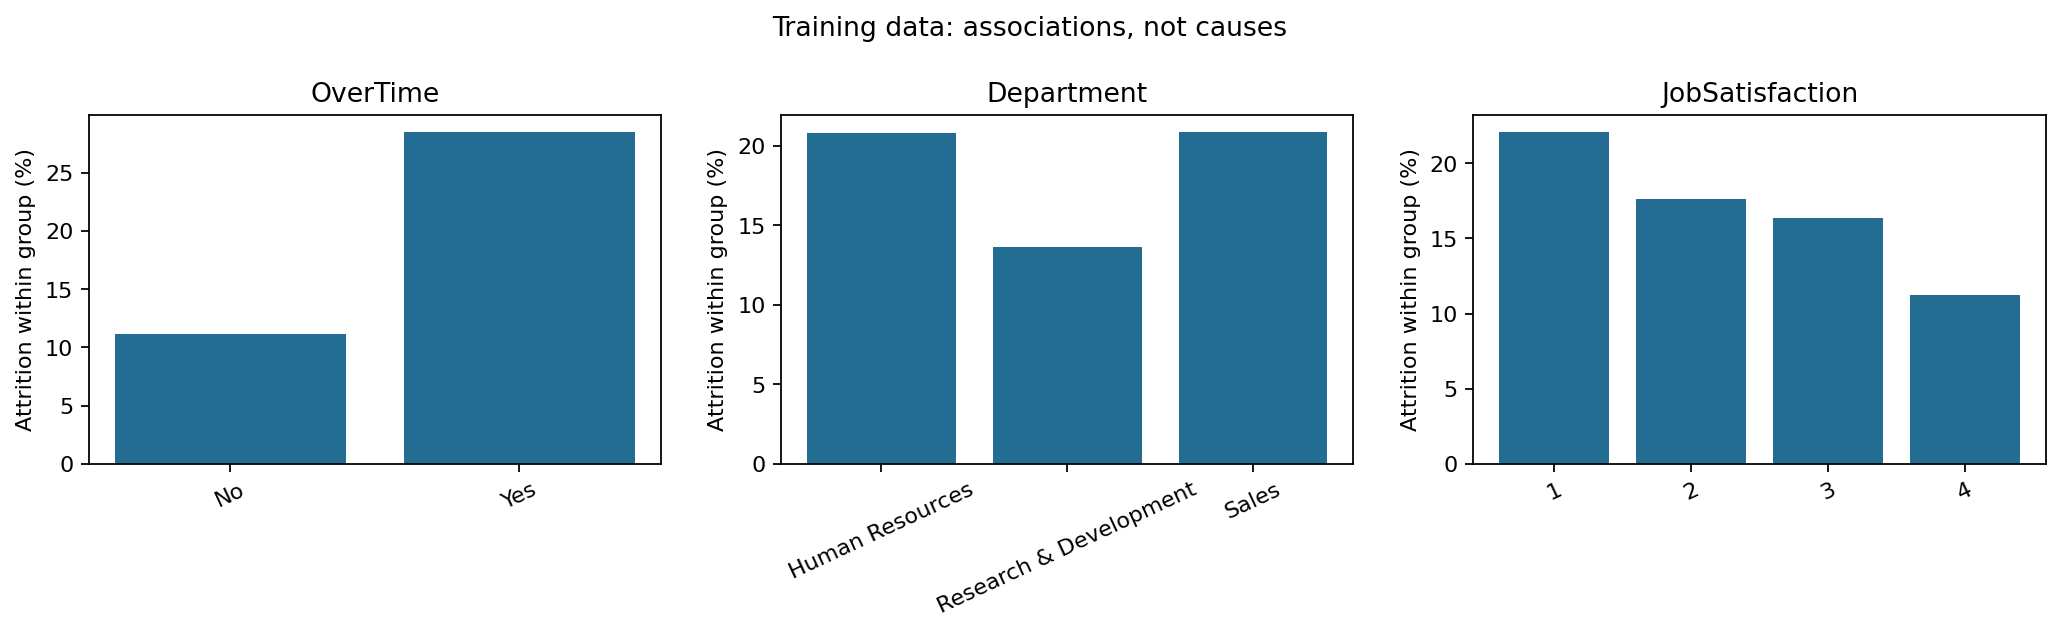

In [4]:
def exploratory_analysis(X_train, y_train):
    """Use training data for exploration so the test set stays held out."""
    OUT.mkdir(exist_ok=True)
    exploratory = X_train.assign(Attrition=y_train)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    tables = []
    for ax, column in zip(axes, ['OverTime', 'Department', 'JobSatisfaction']):
        table = exploratory.groupby(column)['Attrition'].agg(['size', 'sum', 'mean'])
        table.columns = ['employees', 'left', 'attrition_fraction']
        tables.append(table.reset_index().rename(columns={column: 'group'}).assign(feature=column))
        ax.bar(table.index.astype(str), table['attrition_fraction'] * 100, color='#236d93')
        ax.set_title(column)
        ax.set_ylabel('Attrition within group (%)')
        ax.tick_params(axis='x', labelrotation=25)
    fig.suptitle('Training data: associations, not causes')
    fig.tight_layout()
    fig.savefig(OUT / 'training_eda.png', dpi=160, bbox_inches='tight')
    plt.close(fig)
    pd.concat(tables, ignore_index=True).to_csv(OUT / 'training_group_rates.csv', index=False)

exploratory_analysis(X_train, y_train)
print(pd.read_csv(OUT / "training_group_rates.csv").round(3).to_string(index=False))

## 5. Preprocessing and models
Numeric inputs are imputed with the training median and standardized. Categories are imputed with the training mode and one-hot encoded. All transformations stay inside each pipeline to prevent validation data influencing preprocessing.

- **Majority baseline:** always predicts the common class.
- **Logistic Regression:** a simple, explainable linear classifier.
- **Decision Tree:** bounded depth to limit overfitting.
- **Random Forest:** averages multiple trees.

The learned models use class weights to give the minority class more influence. Their output scores are not validated as calibrated personal resignation probabilities.

In [5]:
def make_models(X_train):
    numeric = X_train.select_dtypes(include='number').columns.tolist()
    categorical = X_train.select_dtypes(exclude='number').columns.tolist()
    preprocessing = ColumnTransformer([
        ('numeric', Pipeline([('impute', SimpleImputer(strategy='median')),
                              ('scale', StandardScaler())]), numeric),
        ('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(handle_unknown='ignore'))]), categorical),
    ])
    estimators = {
        'Majority baseline': DummyClassifier(strategy='most_frequent'),
        'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED),
        'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                               class_weight='balanced', random_state=SEED),
        'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8,
                                               min_samples_leaf=3, class_weight='balanced',
                                               random_state=SEED, n_jobs=1),
    }
    return {name: Pipeline([('prepare', clone(preprocessing)), ('model', model)])
            for name, model in estimators.items()}

models = make_models(X_train)

## 6. Select using training cross-validation
Five stratified folds provide repeated validation within training data. Choose the highest mean **average precision (AP)**, a ranking metric emphasizing the minority class. AP is not ordinary precision and is not the same calculation as trapezoidal PR area. Fold standard deviations describe variation, not confidence intervals. No hyperparameter search or threshold tuning is performed.

In [6]:
def compare_models(models, X_train, y_train):
    # Every fold fits its own imputer, encoder and scaler via the pipeline.
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = {'average_precision': 'average_precision', 'f1': 'f1',
              'recall': 'recall', 'accuracy': 'accuracy'}
    rows = []
    for name, pipeline in models.items():
        result = cross_validate(pipeline, X_train, y_train, cv=folds,
                                scoring=scores, n_jobs=1, error_score='raise')
        row = {'model': name}
        for metric in scores:
            row[f'{metric}_mean'] = float(result[f'test_{metric}'].mean())
            row[f'{metric}_std'] = float(result[f'test_{metric}'].std())
        rows.append(row)
    return pd.DataFrame(rows).sort_values('average_precision_mean', ascending=False)

comparison = compare_models(models, X_train, y_train)
comparison.to_csv(OUT / "cv_comparison.csv", index=False)
selected = comparison.iloc[0]["model"]
print(comparison.round(3).to_string(index=False))
print("Selected:", selected)

              model  average_precision_mean  average_precision_std  f1_mean  f1_std  recall_mean  recall_std  accuracy_mean  accuracy_std
Logistic Regression                   0.605                  0.082    0.499   0.021        0.737       0.047          0.761         0.019
      Random Forest                   0.569                  0.048    0.424   0.084        0.332       0.089          0.858         0.015
      Decision Tree                   0.357                  0.052    0.357   0.022        0.516       0.084          0.701         0.038
  Majority baseline                   0.162                  0.000    0.000   0.000        0.000       0.000          0.838         0.000
Selected: Logistic Regression


## 7. Final held-out evaluation
Fit the selected model on all training rows and compare it with the baseline. Use the predefined 0.5 threshold.

**Precision:** among predicted leavers, how many left? **Recall:** among actual leavers, how many were detected? **F1:** balances precision and recall. **ROC-AUC/AP:** evaluate ranking across thresholds. In the confusion matrix, rows are actual labels and columns are predictions; the order is stayed, left.

{
  "Majority baseline": {
    "accuracy": 0.8401360544217688,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "roc_auc": 0.5,
    "average_precision": 0.1598639455782313,
    "confusion_matrix": [
      [
        247,
        0
      ],
      [
        47,
        0
      ]
    ]
  },
  "Logistic Regression": {
    "accuracy": 0.7619047619047619,
    "precision": 0.35802469135802467,
    "recall": 0.6170212765957447,
    "f1": 0.453125,
    "roc_auc": 0.7762081143940046,
    "average_precision": 0.5325077226170596,
    "confusion_matrix": [
      [
        195,
        52
      ],
      [
        18,
        29
      ]
    ]
  }
}


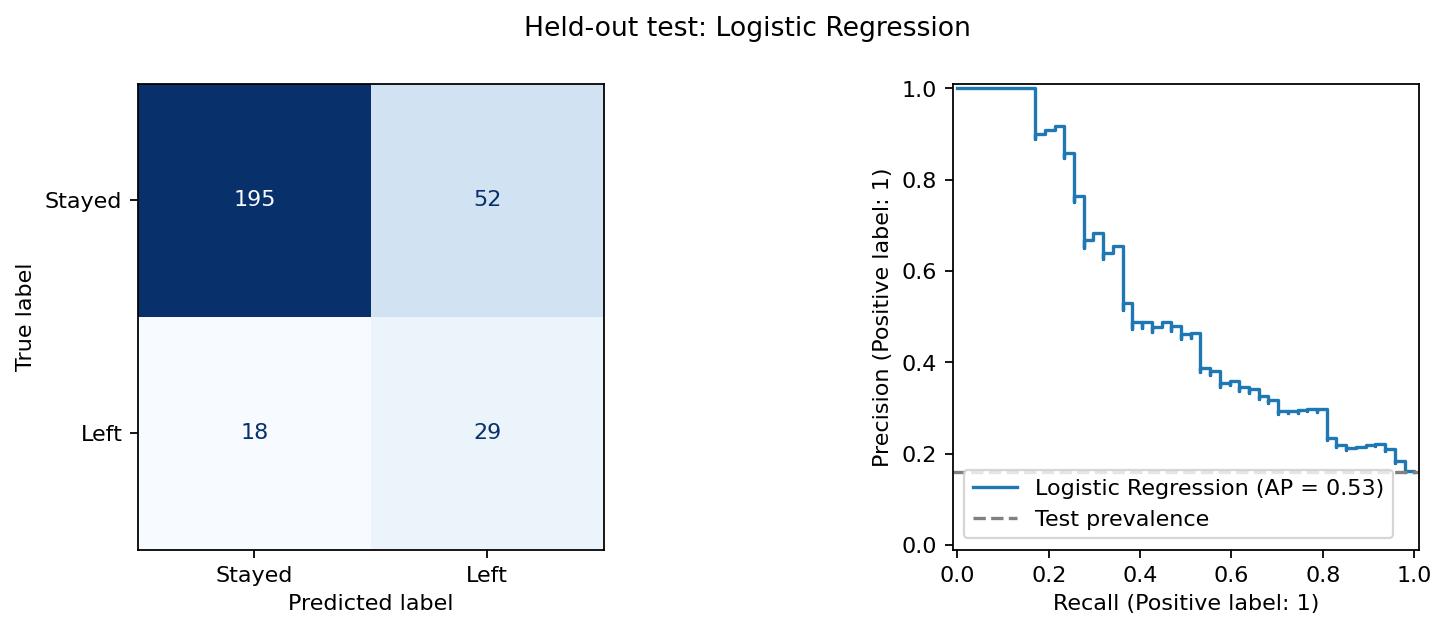

In [7]:
def final_evaluation(models, selected, X_train, X_test, y_train, y_test):
    """Evaluate the CV-selected model and predefined baseline at threshold 0.5."""
    results = {}
    fitted = None
    for name in dict.fromkeys(['Majority baseline', selected]):
        pipeline = models[name].fit(X_train, y_train)
        probabilities = pipeline.predict_proba(X_test)[:, 1]
        predictions = (probabilities >= 0.5).astype(int)
        results[name] = {
            'accuracy': float(accuracy_score(y_test, predictions)),
            'precision': float(precision_score(y_test, predictions, zero_division=0)),
            'recall': float(recall_score(y_test, predictions, zero_division=0)),
            'f1': float(f1_score(y_test, predictions, zero_division=0)),
            'roc_auc': float(roc_auc_score(y_test, probabilities)),
            'average_precision': float(average_precision_score(y_test, probabilities)),
            'confusion_matrix': confusion_matrix(y_test, predictions, labels=[0, 1]).tolist(),
        }
        if name == selected:
            fitted = pipeline
            pd.DataFrame({'source_row': X_test.index, 'actual_left': y_test,
                          'predicted_left': predictions, 'score': probabilities}).to_csv(
                              OUT / 'test_predictions.csv', index=False)
            fig, axes = plt.subplots(1, 2, figsize=(11, 4))
            ConfusionMatrixDisplay.from_predictions(y_test, predictions, labels=[0, 1],
                display_labels=['Stayed', 'Left'], ax=axes[0], colorbar=False, cmap='Blues')
            PrecisionRecallDisplay.from_predictions(y_test, probabilities, ax=axes[1], name=selected)
            axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='Test prevalence')
            axes[1].legend()
            fig.suptitle(f'Held-out test: {selected}')
            fig.tight_layout()
            fig.savefig(OUT / 'test_evaluation.png', dpi=160, bbox_inches='tight')
            plt.close(fig)
    return results, fitted

results, fitted = final_evaluation(models, selected, X_train, X_test, y_train, y_test)
print(json.dumps(results, indent=2))

## 8. What to explain in your viva
1. Why can accuracy be misleading when most employees stayed?
2. Why must scaling and encoding happen inside cross-validation?
3. What is the difference between precision and recall for the left class?
4. Why was the model selected using training folds instead of test accuracy?
5. What does a false positive mean in this project?

**Limitations:** small educational dataset; one random holdout; no external or time-based validation; no causal findings; no fairness or calibration assessment. The model classifies dataset labels rather than establishing when someone will resign. It should not be used to make employment decisions.

**Future work:** nested cross-validation, validation-only threshold selection, calibration assessment, and external validation if an appropriate dataset becomes available.

**Attribution:** dataset from Kaggle; implementation and explanations prepared with Codex assistance. Review and understand the code before presenting it as your project.

Method reference: [scikit-learn guidance on avoiding data leakage](https://scikit-learn.org/1.8/common_pitfalls.html).